# Eksplorasi: Customer Churn Prediction (Klasifikasi Biner)

Tujuan notebook ini: Mengecek kekuatan prediktif fitur sejarah pengguna (sampai cutoff date) terhadap probabilitas pengguna Churn (1) atau Retained (0) di masa depan (90 hari setelah cutoff).

**Pendekatan:** Menggunakan **Klasifikasi Biner** dengan penanganan *Class Imbalance* menggunakan `scale_pos_weight` di XGBoost.

Struktur:
1. Load parquet & cek Class Imbalance
2. Distribusi Target
3. Diagnostik Korelasi (Fitur vs Churn)
4. Baseline Klasifikasi (XGBClassifier) & Feature Importance
5. Kesimpulan

In [3]:
import pandas as pd
import numpy as np
import os
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import cross_val_predict, StratifiedKFold
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from category_encoders import TargetEncoder
from xgboost import XGBClassifier
from sklearn.metrics import classification_report, roc_auc_score, average_precision_score, confusion_matrix, ConfusionMatrixDisplay

pd.set_option('display.max_columns', None)

## 1. Load Parquet & Cek Distribusi Target
Memuat dataset training yang digenerate menggunakan teknik Cutoff Date.

Shape: (18728, 27)
Persentase User Churn (1): 93.64%
Persentase User Retained (0): 6.36%


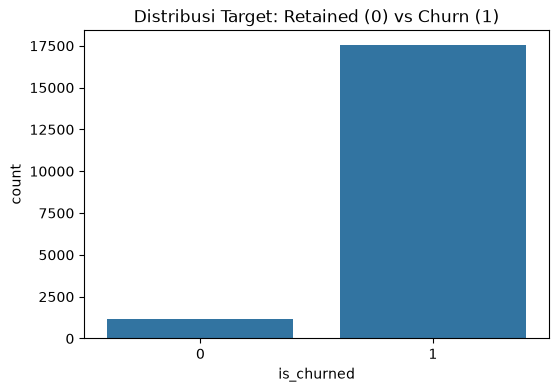

,user_id,is_churned,user_age,user_gender,user_country,primary_traffic_source,recency_days,frequency_total_orders,monetary_total_spent,monetary_aov,customer_tenure_days,avg_days_between_orders,is_single_order_user,avg_item_price,total_discount_enjoyed,unique_categories_bought,favorite_category,total_cancelled_orders,total_returned_orders,return_rate_pct,late_deliveries_experienced,avg_delivery_time_days,total_web_sessions,total_page_views,avg_page_views_per_session,cart_abandonment_count,primary_browser
0,8.0,1,70,M,Japan,Organic,79.051389,1,0.0,0.0,0.0,NaN,1,40.345000,0.0,2,Active,0,0,0.0,0,0.000000,2,14,7.000000,2,Firefox
1,9.0,1,39,M,China,Organic,497.031250,1,0.0,0.0,0.0,NaN,1,117.885000,0.0,4,Outerwear & Coats,0,0,0.0,0,0.000000,4,52,13.000000,12,Chrome
2,17.0,1,29,M,United Kingdom,Search,338.258333,3,0.0,0.0,502.0,251.0,0,106.855714,0.0,6,Outerwear & Coats,0,0,0.0,0,1.717361,7,71,10.142857,14,Chrome
3,29.0,1,34,F,United States,Search,562.000000,1,0.0,0.0,0.0,NaN,1,24.990000,0.0,1,Tops & Tees,0,0,0.0,0,0.000000,1,5,5.000000,0,Chrome
4,33.0,0,30,M,Japan,Facebook,249.688889,1,0.0,0.0,0.0,NaN,1,49.990000,0.0,1,Jeans,0,0,0.0,0,0.000000,1,5,5.000000,0,Other


In [4]:
# Gunakan path sesuai folder dataset Anda
PARQUET_DIR = r"D:\PREP_INTERN\PROJECT_DATAFLOW_SIMULATION\datasets\parquet"
PARQUET_FILE = os.path.join(PARQUET_DIR, "ml_churn_training_dataset_latest.parquet")

df = pd.read_parquet(PARQUET_FILE)
print(f"Shape: {df.shape}")

# NAMA KOLOM TARGET SESUAI SQL ANDA
target_col = "is_churned"

# Cek Class Imbalance
churn_rate = df[target_col].mean() * 100
print(f"Persentase User Churn (1): {churn_rate:.2f}%")
print(f"Persentase User Retained (0): {100 - churn_rate:.2f}%")

plt.figure(figsize=(6, 4))
sns.countplot(data=df, x=target_col)
plt.title("Distribusi Target: Retained (0) vs Churn (1)")
plt.show()

df.head()

## 2. Diagnostik Korelasi (Sinyal Fitur)
Melihat korelasi antara fitur numerik terhadap probabilitas Churn.

In [5]:
# Kecualikan kolom identifier (user_id) dan target
exclude_cols = ['user_id', target_col]
feature_cols = [c for c in df.columns if c not in exclude_cols]

numeric_features = df[feature_cols].select_dtypes(include=['number']).columns.tolist()
categorical_features = [c for c in feature_cols if c not in numeric_features]

print("=" * 60)
print(f"KORELASI (Pearson) vs {target_col}")
print("=" * 60)

corr_matrix = df[numeric_features + [target_col]].corr()
target_corr = corr_matrix[target_col].drop(target_col).sort_values(ascending=False)

for feat, score in target_corr.items():
    print(f"{feat:<35s} Corr = {score:.4f}")

KORELASI (Pearson) vs is_churned
recency_days                        Corr = 0.0328
is_single_order_user                Corr = 0.0188
avg_delivery_time_days              Corr = 0.0092
late_deliveries_experienced         Corr = 0.0073
avg_days_between_orders             Corr = 0.0070
return_rate_pct                     Corr = 0.0043
total_returned_orders               Corr = 0.0039
user_age                            Corr = -0.0006
avg_page_views_per_session          Corr = -0.0042
cart_abandonment_count              Corr = -0.0070
avg_item_price                      Corr = -0.0071
customer_tenure_days                Corr = -0.0078
monetary_total_spent                Corr = -0.0078
total_page_views                    Corr = -0.0084
monetary_aov                        Corr = -0.0094
total_web_sessions                  Corr = -0.0096
frequency_total_orders              Corr = -0.0106
unique_categories_bought            Corr = -0.0111
total_cancelled_orders              Corr = -0.0132
total

## 3. Baseline Classification (XGBoost)
Evaluasi Model Klasifikasi Churn menggunakan 5-Fold Cross-Validation dan kalkulasi bobot khusus untuk kelas minoritas agar algoritma tidak bias.

Menggunakan scale_pos_weight: 0.07

EVALUASI KLASIFIKASI CHURN (Out-of-Fold)
ROC-AUC Score : 0.5115
PR-AUC Score  : 0.9385

              precision    recall  f1-score   support

Retained (0)       0.07      0.32      0.11      1191
   Churn (1)       0.94      0.71      0.81     17537

    accuracy                           0.68     18728
   macro avg       0.50      0.51      0.46     18728
weighted avg       0.88      0.68      0.76     18728



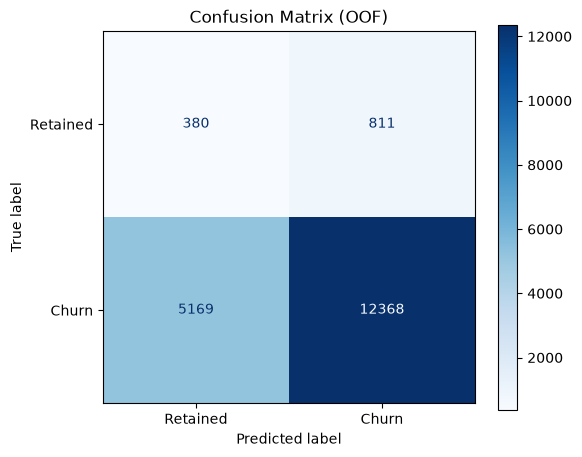


TOP 15 FEATURE IMPORTANCE:
                        Feature  Importance
0   late_deliveries_experienced    0.058777
1            total_web_sessions    0.058329
2               primary_browser    0.052679
3    avg_page_views_per_session    0.051665
4                  user_country    0.049983
5      unique_categories_bought    0.049274
6                avg_item_price    0.049179
7                  recency_days    0.048347
8             favorite_category    0.047729
9        avg_delivery_time_days    0.046444
10                     user_age    0.045758
11         monetary_total_spent    0.045414
12         customer_tenure_days    0.044732
13       primary_traffic_source    0.044579
14             total_page_views    0.043276


In [6]:
X = df[feature_cols]
y = df[target_col]

numeric_transformer = Pipeline([('imputer', SimpleImputer(strategy='constant', fill_value=0))])
categorical_transformer = Pipeline([
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('target_encoder', TargetEncoder())
])

preprocessor = ColumnTransformer([
    ('num', numeric_transformer, numeric_features),
    ('cat', categorical_transformer, categorical_features)
], remainder='drop')

# ==============================================================================
# STRATEGI IMBALANCE: Menghitung scale_pos_weight
# ==============================================================================
total_negative = (y == 0).sum()
total_positive = (y == 1).sum()
pos_weight = total_negative / total_positive if total_positive > 0 else 1

print(f"Menggunakan scale_pos_weight: {pos_weight:.2f}")

pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('classifier', XGBClassifier(
        n_estimators=100, max_depth=5, learning_rate=0.1,
        objective='binary:logistic', tree_method='hist',
        scale_pos_weight=pos_weight, # Penanganan class imbalance
        random_state=42, n_jobs=2
    ))
])

# Stratified K-Fold agar rasio 0 dan 1 merata di setiap fold
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
oof_proba = cross_val_predict(pipeline, X, y, cv=cv, method='predict_proba', n_jobs=1)[:, 1]
oof_preds = (oof_proba >= 0.5).astype(int)

# Evaluasi Metrik
roc_auc = roc_auc_score(y, oof_proba)
pr_auc = average_precision_score(y, oof_proba)

print("\n" + "=" * 50)
print("EVALUASI KLASIFIKASI CHURN (Out-of-Fold)")
print("=" * 50)
print(f"ROC-AUC Score : {roc_auc:.4f}")
print(f"PR-AUC Score  : {pr_auc:.4f}\n")
print(classification_report(y, oof_preds, target_names=['Retained (0)', 'Churn (1)']))

# Confusion Matrix Visualisasi
fig, ax = plt.subplots(figsize=(6, 5))
cm = confusion_matrix(y, oof_preds)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Retained', 'Churn'])
disp.plot(cmap=plt.cm.Blues, ax=ax, values_format='d')
plt.title("Confusion Matrix (OOF)")
plt.show()

# Feature Importance
pipeline.fit(X, y)
xgb_model = pipeline.named_steps['classifier']
semua_fitur = numeric_features + categorical_features

importance_df = pd.DataFrame({
    'Feature': semua_fitur,
    'Importance': xgb_model.feature_importances_
}).sort_values('Importance', ascending=False).reset_index(drop=True)

print("\nTOP 15 FEATURE IMPORTANCE:")
print(importance_df.head(15))